대분류 중분류 통해서 "어떤 내용 위주의 외국인의 상담 주제"에 따른 분석 결과를 확인해야함. 수단은 안중요해서 다 결측치 처리해도 될듯 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import matplotlib.font_manager as fm

# 한글 폰트 설정
mpl.rcParams['font.family'] = 'Malgun Gothic'
mpl.rcParams['axes.unicode_minus'] = False  # 마이너스 깨짐 방지



In [2]:
file_path = r'서울글로벌센터 접수유형별 언어별 상담실적.csv'
df = pd.read_csv(file_path, encoding='cp949')  # 또는 encoding='utf-8-sig'
df.head()

,년월,기관/유형,한국어,영어,일본어,중국어,베트남어,타갈로그어,몽골어,프랑스어,러시아어,우즈벡어,태국어,네팔어,인도네시아어,파키스탄어(우르두어),아랍어,스페인어,기타언어,합계
0,202502,SNS,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1
1,202502,게시판,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,202502,문자,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
3,202502,방문,20,44,4,42,2,29,0,0,9,3,0,0,0,0,0,0,0,153
4,202502,이동상담,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [3]:
# 컬럼 정보 + 결측치 + 타입
print("컬럼 정보 + 결측치 + 타입")
print(df.info())


컬럼 정보 + 결측치 + 타입
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 489 entries, 0 to 488
Data columns (total 20 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   년월           489 non-null    int64 
 1   기관/유형        489 non-null    object
 2   한국어          489 non-null    int64 
 3   영어           489 non-null    int64 
 4   일본어          489 non-null    int64 
 5   중국어          489 non-null    int64 
 6   베트남어         489 non-null    int64 
 7   타갈로그어        489 non-null    int64 
 8   몽골어          489 non-null    int64 
 9   프랑스어         489 non-null    int64 
 10  러시아어         489 non-null    int64 
 11  우즈벡어         489 non-null    int64 
 12  태국어          489 non-null    int64 
 13  네팔어          489 non-null    int64 
 14  인도네시아어       489 non-null    int64 
 15  파키스탄어(우르두어)  489 non-null    int64 
 16  아랍어          489 non-null    int64 
 17  스페인어         489 non-null    int64 
 18  기타언어         489 non-null    int64 
 19  합계          

In [4]:
# 결측치 개수 확인
missing_values = df.isnull().sum()
print(missing_values)

년월             0
기관/유형          0
한국어            0
영어             0
일본어            0
중국어            0
베트남어           0
타갈로그어          0
몽골어            0
프랑스어           0
러시아어           0
우즈벡어           0
태국어            0
네팔어            0
인도네시아어         0
파키스탄어(우르두어)    0
아랍어            0
스페인어           0
기타언어           0
합계             0
dtype: int64


In [5]:
# 1. 공백 문자열 → NaN
df.replace(r'^\s*$', pd.NA, regex=True, inplace=True)

# 2. '기타'가 포함된 열 제거
df = df.loc[:, ~df.columns.str.contains('기타')]

# 3. '년월'에서 '년'만 추출
df['년도'] = df['년월'].astype(str).str[:4]

# 4. C ~ R 컬럼 정수형 변환 및 결측치 0 처리
numeric_cols = df.columns[2:18]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

# ✅ 국가별 총 상담 건수 계산 (열 기준으로 합계)
nation_sums = df[numeric_cols].sum().sort_values(ascending=False).head(10)

C:\Users\lyjin\AppData\Local\Temp\ipykernel_8492\463249195.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nation_sums.index, y=nation_sums.values, palette='pastel')


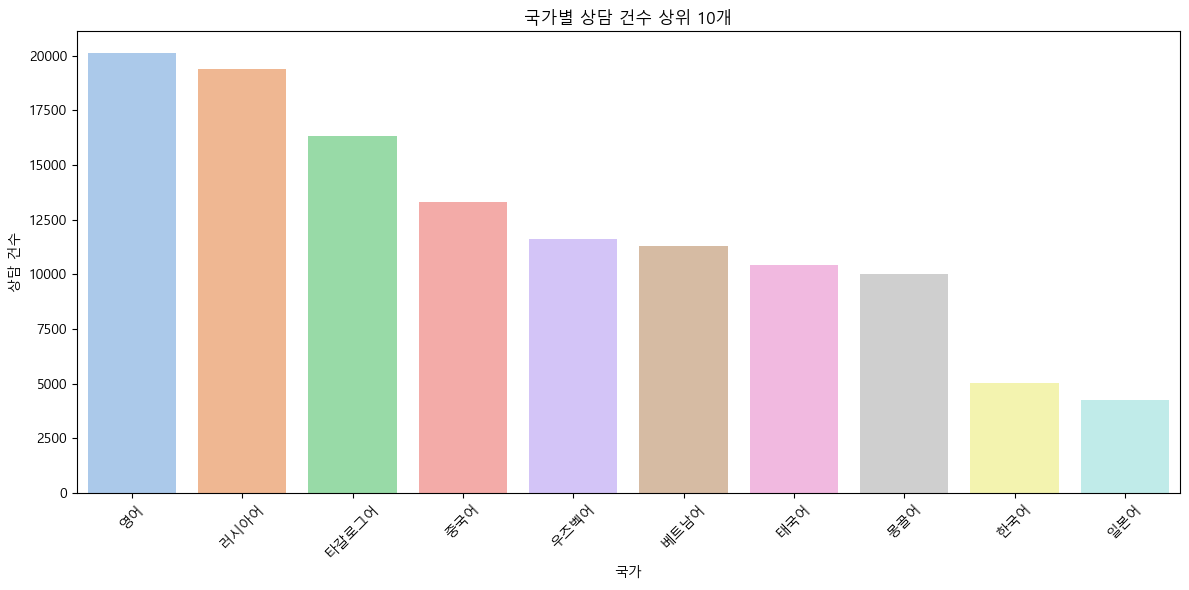

In [6]:
plt.figure(figsize=(12, 6))
sns.barplot(x=nation_sums.index, y=nation_sums.values, palette='pastel')
plt.title('국가별 상담 건수 상위 10개')
plt.xlabel('국가')
plt.ylabel('상담 건수')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
# 데이터를 long-form 으로 변환: 년도, 국가, 상담건수
yearly = df.melt(id_vars='년도', value_vars=numeric_cols,
                 var_name='국적', value_name='상담건수')

# 연도와 국적별로 상담건수 합계 구하기
yearly = yearly.groupby(['년도', '국적'])['상담건수'].sum().reset_index()

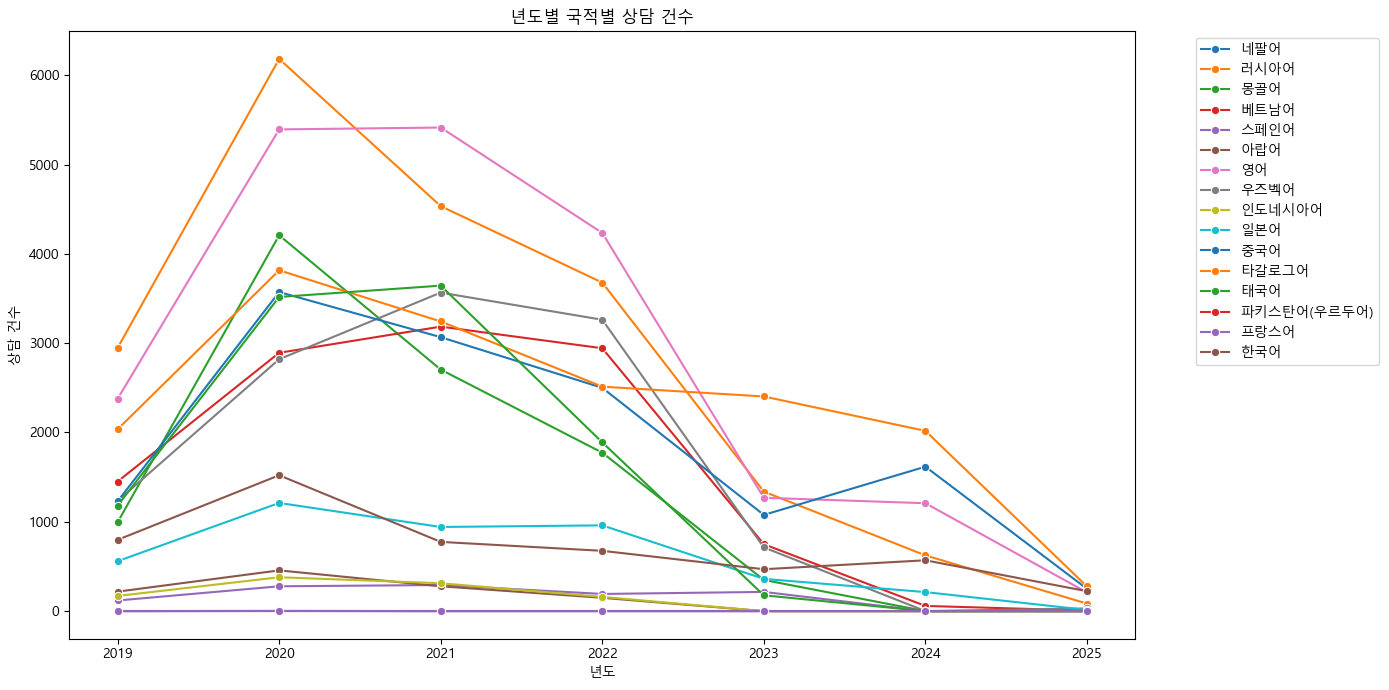

In [8]:
plt.figure(figsize=(14, 7))
sns.lineplot(data=yearly, x='년도', y='상담건수', hue='국적', marker='o', palette='tab10')
plt.title('년도별 국적별 상담 건수')
plt.xlabel('년도')
plt.ylabel('상담 건수')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


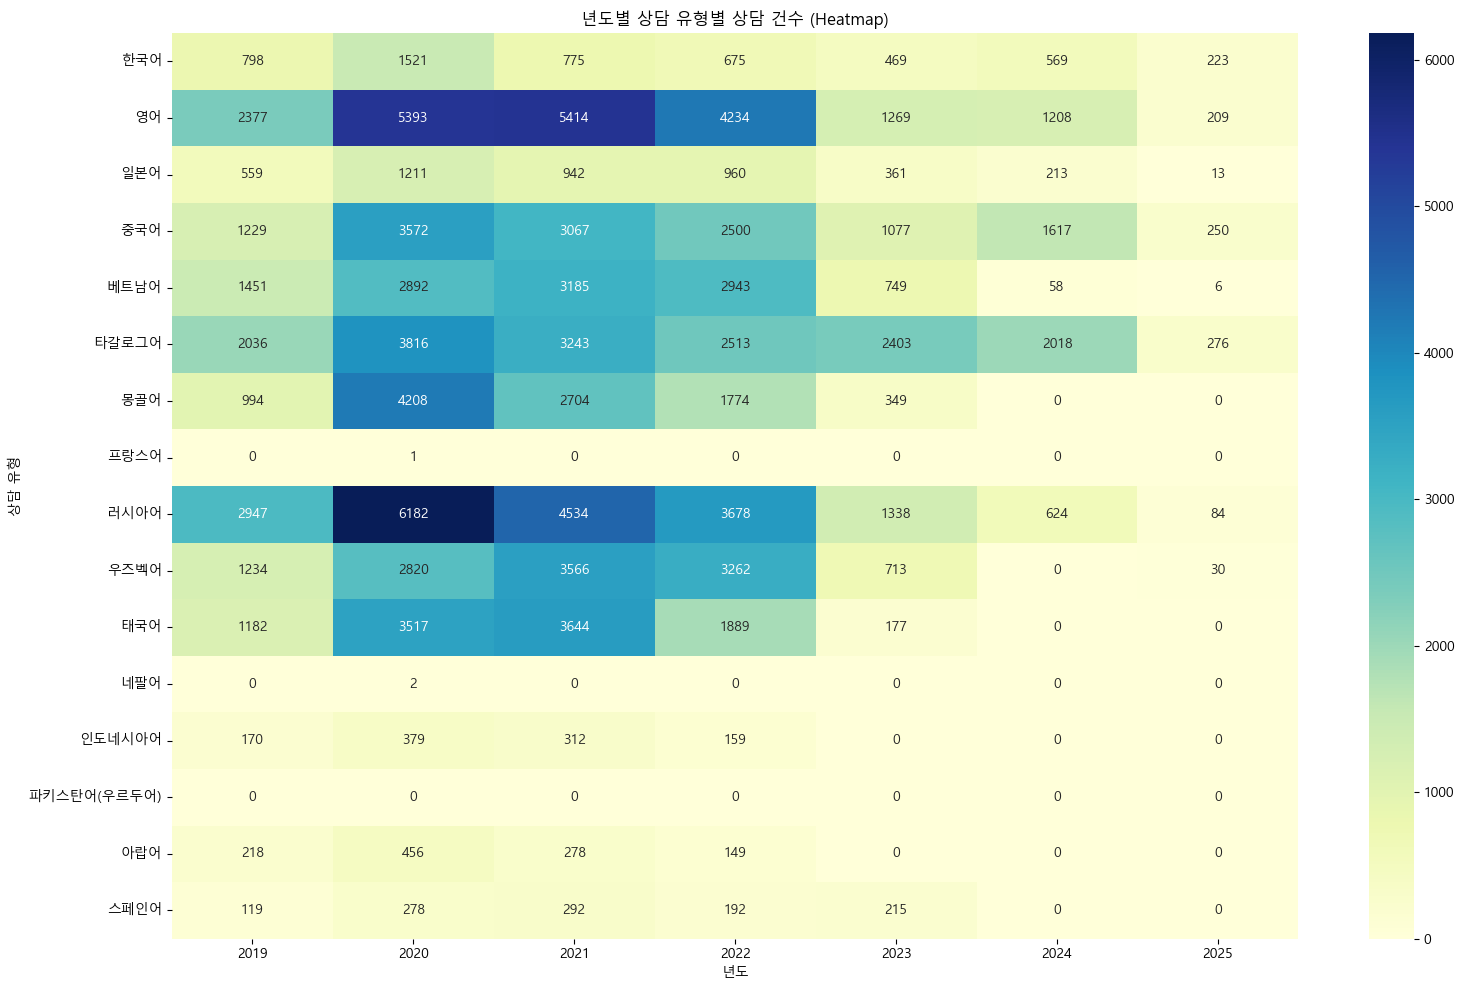

In [9]:
# 년도별 상담 유형별 총합
year_type_sum = df.groupby('년도')[numeric_cols].sum().T

# 시각화
plt.figure(figsize=(16, 10))
sns.heatmap(year_type_sum, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('년도별 상담 유형별 상담 건수 (Heatmap)')
plt.xlabel('년도')
plt.ylabel('상담 유형')
plt.tight_layout()
plt.show()

<Figure size 1600x800 with 0 Axes>

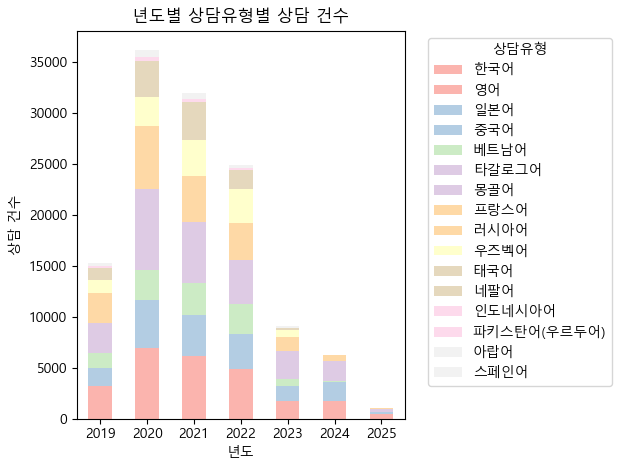

In [10]:
# 1. c~r 열 가져오기 (index 2부터 17까지가 상담유형)
type_cols = df.columns[2:18]

# 2. 년도별 상담유형 합계 계산
year_type_summary = df.groupby('년도')[type_cols].sum()

# 3. 시각화
plt.figure(figsize=(16, 8))
year_type_summary.plot(kind='bar', stacked=True, colormap='Pastel1')
plt.title('년도별 상담유형별 상담 건수')
plt.xlabel('년도')
plt.ylabel('상담 건수')
plt.xticks(rotation=0)
plt.legend(title='상담유형', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()